In [1]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [3]:
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 16, maxR = 10):
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0

In [4]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
def boundary(v):
    return v[1]  * v[0]

In [5]:
target = []
width = range(1, 40)
height = range(1, 40)
for i in width:
    for j in height:
        target.append(np.array([i/20 - 1, j/20 - 1]))

print(len(target))

1521


In [6]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [7]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print(paths1.shape)

(1262, 16, 2)


In [8]:
paths1 = paths1.reshape(-1, 16, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [13]:
class ZNN(keras.Model):
    def __init__(self, units):
        super(ZNN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(2)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [14]:
class YNN(keras.Model):
    def __init__(self, units):
        super(YNN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(1)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [15]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layerZ, layerY):
        super(Ysolver, self).__init__()
        self.Ymodel = YNN(layerY)
        self.Zmodel = ZNN(layerZ)
        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path):
        y_pred = self.Ymodel(path[: , 0])
        #print(path[: , 15].shape)
        for i in range(15): ###input path should be (-1, 2) shaped nparray, no len()
            z = self.Zmodel(path[:, i]) #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            #y_pred += tf.reduce_sum(z * (path[:, i + 1] - path[:, i]), 1, keepdims=True) #accumulating
            forward = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1]
            y_pred += forward
            #print(forward)
        #print(y_pred)
        return y_pred

In [23]:
training = Ysolver([64, 32, 12], [32, 12, 12])
training.compile(
    loss = tf.keras.losses.MeanSquaredError(),
    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    metrics=["mean_absolute_error"],
)

training.fit(paths1, boundary1, batch_size=64, epochs=50, verbose = 2)

Epoch 1/50


2024-02-26 18:04:16.715990: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


20/20 - 9s - loss: 0.2033 - mean_absolute_error: 0.3779 - 9s/epoch - 475ms/step
Epoch 2/50
20/20 - 1s - loss: 0.1600 - mean_absolute_error: 0.3343 - 1s/epoch - 53ms/step
Epoch 3/50
20/20 - 1s - loss: 0.1321 - mean_absolute_error: 0.2967 - 1s/epoch - 51ms/step
Epoch 4/50
20/20 - 1s - loss: 0.1185 - mean_absolute_error: 0.2719 - 1s/epoch - 52ms/step
Epoch 5/50
20/20 - 1s - loss: 0.1139 - mean_absolute_error: 0.2604 - 985ms/epoch - 49ms/step
Epoch 6/50
20/20 - 1s - loss: 0.1116 - mean_absolute_error: 0.2547 - 722ms/epoch - 36ms/step
Epoch 7/50
20/20 - 1s - loss: 0.1111 - mean_absolute_error: 0.2525 - 933ms/epoch - 47ms/step
Epoch 8/50
20/20 - 1s - loss: 0.1104 - mean_absolute_error: 0.2513 - 748ms/epoch - 37ms/step
Epoch 9/50
20/20 - 1s - loss: 0.1106 - mean_absolute_error: 0.2531 - 745ms/epoch - 37ms/step
Epoch 10/50
20/20 - 1s - loss: 0.1098 - mean_absolute_error: 0.2501 - 708ms/epoch - 35ms/step
Epoch 11/50
20/20 - 1s - loss: 0.1093 - mean_absolute_error: 0.2504 - 737ms/epoch - 37ms/st

In [24]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.Ymodel(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)
Z = np.array(Z).reshape(101, 101)

(101, 101)


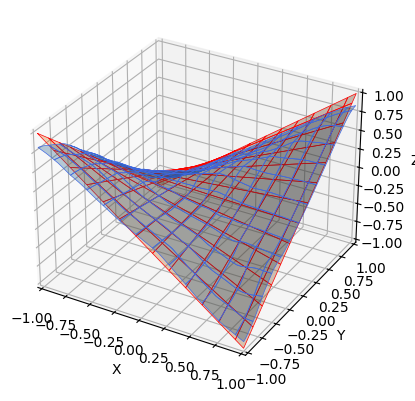

In [25]:
Z1 = Y*X
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()